In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries imported")

✅ Libraries imported


In [2]:
# Load processed dataset with drift scores
df = pd.read_csv(
    "../data/processed/burnout_with_drift.csv"
)

# Feature columns — 14 behavioral + 14 drift + overall drift
feature_cols = [
    "completion_rate", "rework_count",
    "focus_sessions", "avg_focus_duration",
    "context_switches", "idle_time_mins",
    "work_hours_per_day", "after_hours_logins",
    "breaks_taken", "weekend_work_days",
    "error_rate", "submission_delays",
    "revision_requests", "mental_fatigue_score",
    "completion_rate_drift", "rework_count_drift",
    "focus_sessions_drift", "avg_focus_duration_drift",
    "context_switches_drift", "idle_time_mins_drift",
    "work_hours_per_day_drift", "after_hours_logins_drift",
    "breaks_taken_drift", "weekend_work_days_drift",
    "error_rate_drift", "submission_delays_drift",
    "revision_requests_drift", "mental_fatigue_score_drift",
    "overall_drift_score"
]

X = df[feature_cols]
y = df["label_encoded"]

print("✅ Data loaded")
print(f"Features : {X.shape[1]}")
print(f"Samples  : {X.shape[0]}")
print(f"\nLabel distribution:")
print(y.value_counts())
print(f"\nLabel mapping: High=0, Low=1, Medium=2")

✅ Data loaded
Features : 29
Samples  : 1600

Label distribution:
label_encoded
1    600
2    500
0    500
Name: count, dtype: int64

Label mapping: High=0, Low=1, Medium=2


In [3]:
# Split data — 70% train, 15% validation, 15% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.15,
    stratify=y_train,
    random_state=42
)

print("✅ Data split complete")
print(f"Training   : {X_train.shape[0]} samples")
print(f"Validation : {X_val.shape[0]} samples")
print(f"Test       : {X_test.shape[0]} samples")

# Apply SMOTE to balance classes in training set only
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"\n✅ SMOTE applied")
print(f"Training samples after SMOTE: {X_train_res.shape[0]}")
print(f"\nClass distribution after SMOTE:")
print(pd.Series(y_train_res).value_counts())

✅ Data split complete
Training   : 1156 samples
Validation : 204 samples
Test       : 240 samples

✅ SMOTE applied
Training samples after SMOTE: 1302

Class distribution after SMOTE:
label_encoded
2    434
1    434
0    434
Name: count, dtype: int64


In [4]:
# Train XGBoost classifier
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric="mlogloss",
    random_state=42
)

xgb.fit(
    X_train_res, y_train_res,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print("✅ XGBoost training complete")

# Evaluate on test set
y_pred = xgb.predict(X_test)

print(f"\nTest Set Results:")
print(classification_report(
    y_test, y_pred,
    target_names=["High", "Low", "Medium"]
))

✅ XGBoost training complete

Test Set Results:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        75
         Low       1.00      1.00      1.00        90
      Medium       1.00      1.00      1.00        75

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



In [5]:
cv_scores = cross_val_score(
    xgb, X, y,
    cv=5,
    scoring="f1_macro"
)

print("Cross Validation Results")
print(f"F1 Macro per fold : {cv_scores.round(3)}")
print(f"Mean F1 Macro     : {cv_scores.mean():.3f}")
print(f"Std               : {cv_scores.std():.3f}")

y_pred_proba = xgb.predict_proba(X_test)
auc = roc_auc_score(
    y_test,
    y_pred_proba,
    multi_class="ovr",
    average="macro"
)
print(f"\nROC-AUC Score : {auc:.3f}")
print(f"\nTarget was    : AUC ≥ 0.88")
print(f"Result        : {'PASSED' if auc >= 0.88 else 'BELOW TARGET'}")

Cross Validation Results
F1 Macro per fold : [1.    1.    0.997 1.    1.   ]
Mean F1 Macro     : 0.999
Std               : 0.001

ROC-AUC Score : 1.000

Target was    : AUC ≥ 0.88
Result        : PASSED


Top 10 Most Important Features:
             feature  importance
   submission_delays    0.318264
  after_hours_logins    0.183166
    context_switches    0.125531
      idle_time_mins    0.116294
     completion_rate    0.108903
   revision_requests    0.076861
        breaks_taken    0.048413
  avg_focus_duration    0.019764
          error_rate    0.001365
mental_fatigue_score    0.000760


C:\Users\Shubham\AppData\Local\Temp\ipykernel_28528\3087466859.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Shubham\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Shubham\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Shubham\AppData\Local\Programs\Python\Pyt

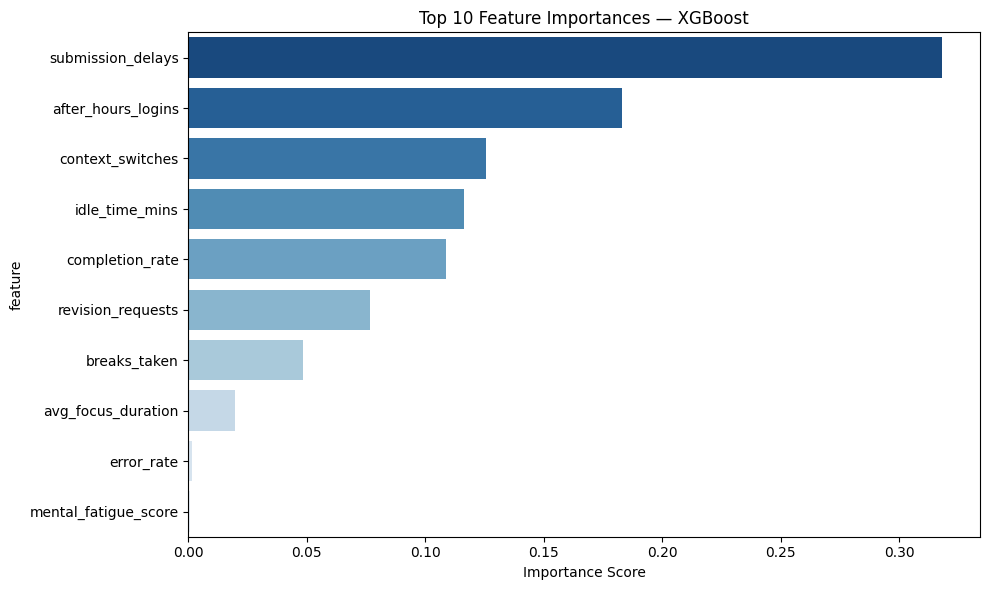

Plot saved to reports/feature_importance.png


In [6]:
importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False)

print("Top 10 Most Important Features:")
print(importance.head(10).to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance.head(10),
    x="importance",
    y="feature",
    palette="Blues_r"
)
plt.title("Top 10 Feature Importances — XGBoost")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig(
    "../reports/feature_importance.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Plot saved to reports/feature_importance.png")

In [7]:
os.makedirs("../models", exist_ok=True)
joblib.dump(xgb,          "../models/xgboost_model.pkl")
joblib.dump(le,           "../models/label_encoder.pkl")
joblib.dump(feature_cols, "../models/feature_cols.pkl")

print(f"\n All models saved to models/ folder")
print("  xgboost_model.pkl")
print("  label_encoder.pkl")
print("  feature_cols.pkl")

NameError: name 'le' is not defined

In [8]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import joblib
import os

df = pd.read_csv("../data/processed/burnout_with_drift.csv")

feature_cols = [
    "completion_rate", "rework_count",
    "focus_sessions", "avg_focus_duration",
    "context_switches", "idle_time_mins",
    "work_hours_per_day", "after_hours_logins",
    "breaks_taken", "weekend_work_days",
    "error_rate", "submission_delays",
    "revision_requests", "mental_fatigue_score",
    "completion_rate_drift", "rework_count_drift",
    "focus_sessions_drift", "avg_focus_duration_drift",
    "context_switches_drift", "idle_time_mins_drift",
    "work_hours_per_day_drift", "after_hours_logins_drift",
    "breaks_taken_drift", "weekend_work_days_drift",
    "error_rate_drift", "submission_delays_drift",
    "revision_requests_drift", "mental_fatigue_score_drift",
    "overall_drift_score"
]

le = LabelEncoder()
df["label_encoded"] = le.fit_transform(df["burnout_label"])

X = df[feature_cols]
y = df["label_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15,
    stratify=y_train, random_state=42
)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric="mlogloss",
    random_state=42
)
xgb.fit(
    X_train_res, y_train_res,
    eval_set=[(X_val, y_val)],
    verbose=False
)

os.makedirs("../models", exist_ok=True)
joblib.dump(xgb,          "../models/xgboost_model.pkl")
joblib.dump(le,           "../models/label_encoder.pkl")
joblib.dump(feature_cols, "../models/feature_cols.pkl")

print(" All models saved")
print(f"  Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

 All models saved
  Label mapping: {'High': 0, 'Low': 1, 'Medium': 2}


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_res, y_train_res)
lr_pred  = lr.predict(X_test)
lr_proba = lr.predict_proba(X_test)

lr_auc = roc_auc_score(
    y_test, lr_proba, multi_class="ovr", average="macro"
)
lr_report = classification_report(
    y_test, lr_pred,
    target_names=["High", "Low", "Medium"],
    output_dict=True
)

print("── Logistic Regression ──────────────────────")
print(classification_report(
    y_test, lr_pred, target_names=["High","Low","Medium"]
))
print(f"AUC: {lr_auc:.3f}")

svm = SVC(probability=True, kernel="rbf", random_state=42)
svm.fit(X_train_res, y_train_res)
svm_pred  = svm.predict(X_test)
svm_proba = svm.predict_proba(X_test)

svm_auc = roc_auc_score(
    y_test, svm_proba, multi_class="ovr", average="macro"
)
svm_report = classification_report(
    y_test, svm_pred,
    target_names=["High", "Low", "Medium"],
    output_dict=True
)

print("── SVM (RBF Kernel) ─────────────────────────")
print(classification_report(
    y_test, svm_pred, target_names=["High","Low","Medium"]
))
print(f"AUC: {svm_auc:.3f}")

xgb_pred  = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)
xgb_auc   = roc_auc_score(
    y_test, xgb_proba, multi_class="ovr", average="macro"
)

print("── XGBoost ──────────────────────────────────")
print(classification_report(
    y_test, xgb_pred, target_names=["High","Low","Medium"]
))
print(f"AUC: {xgb_auc:.3f}")

print("\n Baseline comparison complete")


── Logistic Regression ──────────────────────
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        75
         Low       1.00      1.00      1.00        90
      Medium       1.00      1.00      1.00        75

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240

AUC: 1.000
── SVM (RBF Kernel) ─────────────────────────
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        75
         Low       0.99      1.00      0.99        90
      Medium       1.00      0.99      0.99        75

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240

AUC: 1.000
── XGBoost ──────────────────────────────────
              precision    recall  f1-score   support

        High       1.00

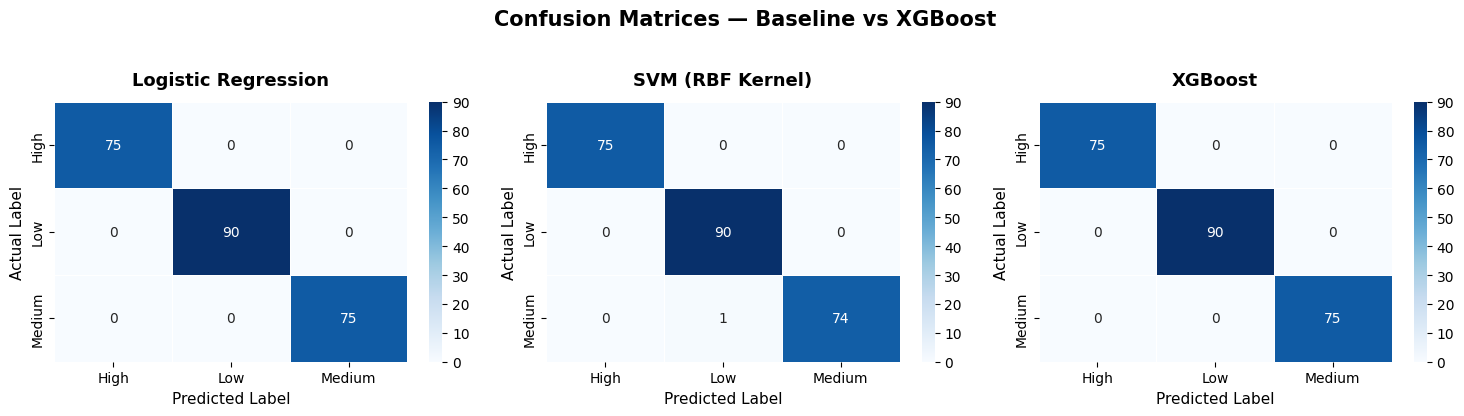

Confusion matrices saved to reports/confusion_matrices.png


In [10]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

labels = ["High", "Low", "Medium"]

# Get all predictions
lr_pred_cm  = lr.predict(X_test)
svm_pred_cm = svm.predict(X_test)
xgb_pred_cm = xgb.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

model_preds = [
    (lr_pred_cm,  "Logistic Regression"),
    (svm_pred_cm, "SVM (RBF Kernel)"),
    (xgb_pred_cm, "XGBoost"),
]

for ax, (preds, title) in zip(axes, model_preds):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax,
        xticklabels=labels, yticklabels=labels,
        cmap="Blues", cbar=True,
        linewidths=0.5, linecolor="white"
    )
    ax.set_title(f"{title}", fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("Actual Label", fontsize=11)

plt.suptitle(
    "Confusion Matrices — Baseline vs XGBoost",
    fontsize=15, fontweight="bold", y=1.03
)
plt.tight_layout()
os.makedirs("../reports", exist_ok=True)
plt.savefig(
    "../reports/confusion_matrices.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Confusion matrices saved to reports/confusion_matrices.png")

In [11]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import joblib
import os

# Load model and features
xgb          = joblib.load("../models/xgboost_model.pkl")
feature_cols = joblib.load("../models/feature_cols.pkl")
le           = joblib.load("../models/label_encoder.pkl")

# ── SHAP TreeExplainer ─────────────────────────────
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

print("✅ SHAP values computed")
print(f"Shape of SHAP values : {np.array(shap_values).shape}")
print(f"Classes              : {le.classes_}")

✅ SHAP values computed
Shape of SHAP values : (240, 29, 3)
Classes              : ['High' 'Low' 'Medium']


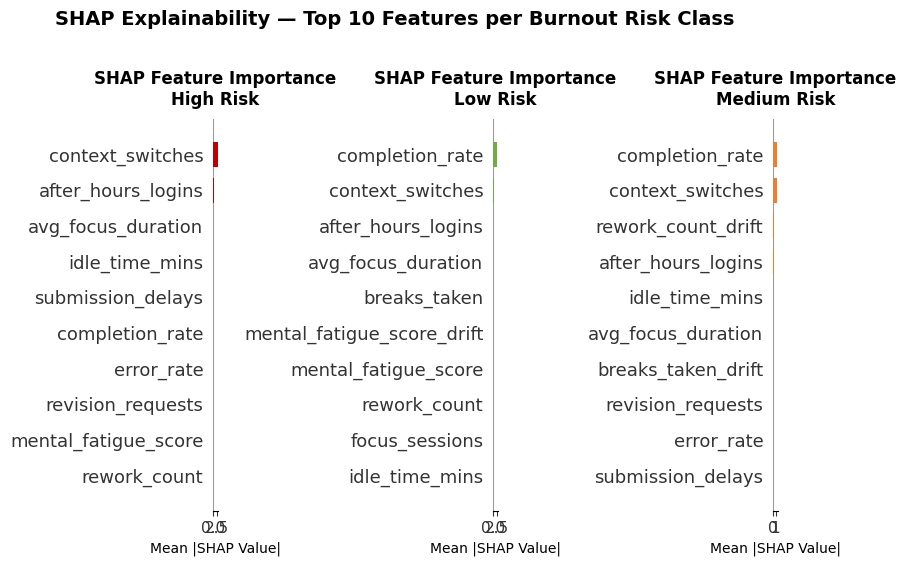

SHAP summary plot saved to reports/shap_summary.png


In [12]:
# ── SHAP Summary Plot — All Classes ───────────────
class_names = ["High Risk", "Low Risk", "Medium Risk"]
colors      = ["#C00000", "#70AD47", "#ED7D31"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (cls, color) in enumerate(zip(class_names, colors)):
    plt.sca(axes[i])
    shap.summary_plot(
        shap_values[:, :, i],
        X_test,
        feature_names=feature_cols,
        plot_type="bar",
        color=color,
        max_display=10,
        show=False
    )
    axes[i].set_title(
        f"SHAP Feature Importance\n{cls}",
        fontsize=12, fontweight="bold", pad=10
    )
    axes[i].set_xlabel("Mean |SHAP Value|", fontsize=10)

plt.suptitle(
    "SHAP Explainability — Top 10 Features per Burnout Risk Class",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
os.makedirs("../reports", exist_ok=True)
plt.savefig(
    "../reports/shap_summary.png",
    dpi=150, bbox_inches="tight",
    facecolor="white"
)
plt.show()
print("SHAP summary plot saved to reports/shap_summary.png")

In [13]:
# ── Top-3 SHAP Alert Reasons per Prediction ───────
def get_alert_reason(shap_vals_row, feature_names, predicted_class):
    """Generate plain-language alert reason from SHAP values."""
    abs_shap = np.abs(shap_vals_row)
    top3_idx = np.argsort(abs_shap)[::-1][:3]

    reasons = []
    for idx in top3_idx:
        feat  = feature_names[idx]
        value = shap_vals_row[idx]
        direction = "increased significantly" if value > 0 else "decreased significantly"

        # Clean feature name for display
        clean = feat.replace("_drift", " (drift)").replace("_", " ").title()
        reasons.append(f"{clean} has {direction}")

    return " | ".join(reasons)

# ── Generate alerts for High and Medium Risk samples
y_pred      = xgb.predict(X_test)
X_test_arr  = X_test.values

print("=" * 70)
print("SHAP-BASED ALERT REASONS — SAMPLE OUTPUT")
print("=" * 70)

shown = {"High": 0, "Medium": 0}
for i in range(len(y_pred)):
    pred_label = le.inverse_transform([y_pred[i]])[0]
    actual_label = le.inverse_transform([y_test.iloc[i]])[0]

    if pred_label in ["High", "Medium"] and shown[pred_label] < 3:
        shap_row = shap_values[i, :, y_pred[i]]
        reason   = get_alert_reason(shap_row, feature_cols, pred_label)

        print(f"\nEmployee Sample #{i+1}")
        print(f"  Predicted Risk : {pred_label}")
        print(f"  Actual Risk    : {actual_label}")
        print(f"  Alert Reason   : {reason}")
        shown[pred_label] += 1

    if shown["High"] >= 3 and shown["Medium"] >= 3:
        break

print("\n" + "=" * 70)

# ── Save alert function for dashboard use ──────────
joblib.dump(explainer, "../models/shap_explainer.pkl")
print("✅ SHAP explainer saved to models/shap_explainer.pkl")

SHAP-BASED ALERT REASONS — SAMPLE OUTPUT

Employee Sample #1
  Predicted Risk : High
  Actual Risk    : High
  Alert Reason   : Context Switches has increased significantly | After Hours Logins has increased significantly | Avg Focus Duration has increased significantly

Employee Sample #2
  Predicted Risk : High
  Actual Risk    : High
  Alert Reason   : Context Switches has increased significantly | After Hours Logins has increased significantly | Avg Focus Duration has increased significantly

Employee Sample #3
  Predicted Risk : Medium
  Actual Risk    : Medium
  Alert Reason   : Context Switches has increased significantly | Completion Rate has increased significantly | After Hours Logins has increased significantly

Employee Sample #4
  Predicted Risk : High
  Actual Risk    : High
  Alert Reason   : Context Switches has increased significantly | After Hours Logins has increased significantly | Avg Focus Duration has increased significantly

Employee Sample #5
  Predicted Risk :

In [14]:
# ── Phase 5 Summary ────────────────────────────────
print("=" * 60)
print("PHASE 5 — SHAP EXPLAINABILITY SUMMARY")
print("=" * 60)

# Overall top features across all classes
mean_shap = np.mean(np.abs(shap_values), axis=(0, 2))
top10_idx = np.argsort(mean_shap)[::-1][:10]

print("\nTop 10 Features by Mean |SHAP| across all classes:")
print(f"{'Rank':<6} {'Feature':<35} {'Mean |SHAP|':<12}")
print("-" * 55)
for rank, idx in enumerate(top10_idx, 1):
    print(f"{rank:<6} {feature_cols[idx]:<35} {mean_shap[idx]:.4f}")

print(f"\nFiles saved:")
print(f"  reports/shap_summary.png")
print(f"  models/shap_explainer.pkl")
print(f"\n Phase 5 Complete")

PHASE 5 — SHAP EXPLAINABILITY SUMMARY

Top 10 Features by Mean |SHAP| across all classes:
Rank   Feature                             Mean |SHAP| 
-------------------------------------------------------
1      context_switches                    1.5652
2      completion_rate                     1.5509
3      after_hours_logins                  0.2599
4      avg_focus_duration                  0.0933
5      rework_count_drift                  0.0738
6      idle_time_mins                      0.0663
7      submission_delays                   0.0369
8      error_rate                          0.0219
9      revision_requests                   0.0184
10     breaks_taken_drift                  0.0141

Files saved:
  reports/shap_summary.png
  models/shap_explainer.pkl

 Phase 5 Complete
